In [2]:
# =============================================================================
# DAY 4 — DATA PREPROCESSING
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Fix TotalCharges (blank strings → float)
#   Task 2 — Drop / clean irrelevant columns
#   Task 3 — Encode binary categorical columns (Yes/No → 1/0)
#   Task 4 — One-hot encode multi-class categorical columns
#   Task 5 — Scale numerical features
#   Task 6 — Feature engineering (new derived columns)
#   Task 7 — Save cleaned dataset to CSV & SQLite
#   Task 8 — Preprocessing summary report
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sqlalchemy import create_engine
import os
import warnings

warnings.filterwarnings("ignore")

# ── PATHS ────────────────────────────────────────────────────────────────────
DATA_PATH    = "C:/Users/white/Downloads/Learn/Churn_project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
CLEAN_PATH   = "C:/Users/white/Downloads/Learn/Churn_project/data/churn_cleaned.csv"
DB_PATH      = "C:/Users/white/Downloads/Learn/Churn_project/data/churn.db"
VISUALS_PATH = "C:/Users/white/Downloads/Learn/Churn_project/visuals/day4_preprocessing.png"

os.makedirs("../data",    exist_ok=True)
os.makedirs("../visuals", exist_ok=True)

print("=" * 60)
print("  DAY 4 — DATA PREPROCESSING")
print("=" * 60)


# ── LOAD RAW DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"\n  Raw data loaded   : {df.shape[0]:,} rows × {df.shape[1]} columns")

  DAY 4 — DATA PREPROCESSING

  Raw data loaded   : 7,043 rows × 21 columns


In [3]:
# =============================================================================
# TASK 1 — FIX TotalCharges (blank strings → NaN → float → impute)
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 1 — Fix TotalCharges")
print("=" * 60)

# Step 1a: Replace blank strings with NaN
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", np.nan)

# Step 1b: Convert to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Step 1c: Identify affected rows (tenure=0 → new customers, charge not yet billed)
tc_nulls_before = df["TotalCharges"].isnull().sum()
print(f"  NaN rows after conversion : {tc_nulls_before}")
print(f"  Tenure of those rows      : {df[df['TotalCharges'].isnull()]['tenure'].unique().tolist()}")

# Step 1d: Impute — for tenure=0 customers, TotalCharges should be 0.0
df.loc[df["TotalCharges"].isnull(), "TotalCharges"] = 0.0
print(f"  NaN rows after imputation : {df['TotalCharges'].isnull().sum()}")
print("  -> Imputed with 0.0 (new customers not yet billed)  ✓")


  TASK 1 — Fix TotalCharges
  NaN rows after conversion : 11
  Tenure of those rows      : [0]
  NaN rows after imputation : 0
  -> Imputed with 0.0 (new customers not yet billed)  ✓


In [ ]:
# =============================================================================
# TASK 2 — DROP / CLEAN IRRELEVANT COLUMNS
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 2 — Drop irrelevant columns")
print("=" * 60)

# customerID is a unique identifier — leaks nothing useful to the model
df.drop(columns=["customerID"], inplace=True)
print("  Dropped : customerID  ✓")
print(f"  Shape after drop : {df.shape[0]:,} rows × {df.shape[1]} columns")


  TASK 2 — Drop irrelevant columns
  Dropped : customerID  ✓
  Shape after drop : 7,043 rows × 20 columns


In [5]:
# =============================================================================
# TASK 3 — ENCODE BINARY CATEGORICAL COLUMNS (Yes/No → 1/0)
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 3 — Binary encoding (Yes/No → 1/0)")
print("=" * 60)

# Columns with a simple Yes / No mapping
binary_yes_no = [
    "Partner", "Dependents", "PhoneService",
    "PaperlessBilling", "Churn"
]

for col in binary_yes_no:
    df[col] = df[col].map({"Yes": 1, "No": 0})
    print(f"  {col:<22} : Yes→1 / No→0  ✓")

# gender: Male / Female → 1 / 0
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
print(f"  {'gender':<22} : Male→1 / Female→0  ✓")

# SeniorCitizen is already 0/1 — confirm
print(f"  {'SeniorCitizen':<22} : already 0/1  ✓")


  TASK 3 — Binary encoding (Yes/No → 1/0)
  Partner                : Yes→1 / No→0  ✓
  Dependents             : Yes→1 / No→0  ✓
  PhoneService           : Yes→1 / No→0  ✓
  PaperlessBilling       : Yes→1 / No→0  ✓
  Churn                  : Yes→1 / No→0  ✓
  gender                 : Male→1 / Female→0  ✓
  SeniorCitizen          : already 0/1  ✓


In [6]:
# =============================================================================
# TASK 4 — ONE-HOT ENCODE MULTI-CLASS CATEGORICAL COLUMNS
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 4 — One-hot encoding (multi-class categoricals)")
print("=" * 60)

# Columns with 3+ categories
ohe_columns = [
    "MultipleLines",       # No / Yes / No phone service
    "InternetService",     # DSL / Fiber optic / No
    "OnlineSecurity",      # No / Yes / No internet service
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",            # Month-to-month / One year / Two year
    "PaymentMethod"        # 4 payment methods
]

df_before_ohe = df.shape[1]

df = pd.get_dummies(df, columns=ohe_columns, drop_first=False)

# Convert all new bool columns (pandas ≥ 1.0 get_dummies) to int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

df_after_ohe = df.shape[1]
print(f"  Columns before OHE : {df_before_ohe}")
print(f"  Columns after  OHE : {df_after_ohe}")
print(f"  New dummy columns  : {df_after_ohe - df_before_ohe}")
print("  One-hot encoding complete  ✓")

# Show all OHE column names created
print("\n  New dummy columns created:")
original_non_ohe = set(df.columns) - set(ohe_columns)
for col in df.columns:
    for base in ohe_columns:
        if col.startswith(base + "_"):
            print(f"    {col}")
            break


  TASK 4 — One-hot encoding (multi-class categoricals)
  Columns before OHE : 20
  Columns after  OHE : 41
  New dummy columns  : 21
  One-hot encoding complete  ✓

  New dummy columns created:
    MultipleLines_No
    MultipleLines_No phone service
    MultipleLines_Yes
    InternetService_DSL
    InternetService_Fiber optic
    InternetService_No
    OnlineSecurity_No
    OnlineSecurity_No internet service
    OnlineSecurity_Yes
    OnlineBackup_No
    OnlineBackup_No internet service
    OnlineBackup_Yes
    DeviceProtection_No
    DeviceProtection_No internet service
    DeviceProtection_Yes
    TechSupport_No
    TechSupport_No internet service
    TechSupport_Yes
    StreamingTV_No
    StreamingTV_No internet service
    StreamingTV_Yes
    StreamingMovies_No
    StreamingMovies_No internet service
    StreamingMovies_Yes
    Contract_Month-to-month
    Contract_One year
    Contract_Two year
    PaymentMethod_Bank transfer (automatic)
    PaymentMethod_Credit card (automatic)
 

In [7]:
# =============================================================================
# TASK 5 — SCALE NUMERICAL FEATURES
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 5 — Scale numerical features (MinMax 0–1)")
print("=" * 60)

# Numerical columns to scale
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Keep unscaled versions for reference / interpretability
for col in num_cols:
    df[f"{col}_raw"] = df[col]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

for col in num_cols:
    print(f"  {col:<20} : min={df[col].min():.2f}  max={df[col].max():.2f}  "
          f"(raw range preserved in {col}_raw)  ✓")

print("\n  Note: raw columns (_raw) are kept for EDA/reporting use.")
print("        Drop them before feeding to sklearn models.")


  TASK 5 — Scale numerical features (MinMax 0–1)
  tenure               : min=0.00  max=1.00  (raw range preserved in tenure_raw)  ✓
  MonthlyCharges       : min=0.00  max=1.00  (raw range preserved in MonthlyCharges_raw)  ✓
  TotalCharges         : min=0.00  max=1.00  (raw range preserved in TotalCharges_raw)  ✓

  Note: raw columns (_raw) are kept for EDA/reporting use.
        Drop them before feeding to sklearn models.


In [8]:
# =============================================================================
# TASK 6 — FEATURE ENGINEERING
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 6 — Feature engineering")
print("=" * 60)

# Use _raw columns so we work in the original units
# 6a: Charge-per-month ratio (Total / tenure) — measures billing consistency
df["charge_per_month"] = np.where(
    df["tenure_raw"] == 0,
    df["MonthlyCharges_raw"],                                  # tenure=0 → use monthly
    df["TotalCharges_raw"] / df["tenure_raw"]
)
print("  charge_per_month     : TotalCharges / tenure  ✓")

# 6b: High value customer flag (MonthlyCharges > 75th percentile)
p75 = df["MonthlyCharges_raw"].quantile(0.75)
df["high_value"] = (df["MonthlyCharges_raw"] >= p75).astype(int)
print(f"  high_value           : MonthlyCharges ≥ ${p75:.2f} → 1 else 0  ✓")

# 6c: Number of add-on services subscribed
addon_base_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
# Use the OHE _Yes columns created in Task 4
addon_yes_cols = [c for c in df.columns if any(c == f"{a}_Yes" for a in addon_base_cols)]
df["num_addons"] = df[addon_yes_cols].sum(axis=1)
print(f"  num_addons           : sum of {len(addon_yes_cols)} add-on _Yes flags  ✓")

# 6d: Tenure bucket (early / mid / long)
df["tenure_bucket"] = pd.cut(
    df["tenure_raw"],
    bins=[0, 12, 36, 72],
    labels=[0, 1, 2],          # 0=early, 1=mid, 2=long
    include_lowest=True
).astype(int)
print("  tenure_bucket        : 0=early(≤12mo) / 1=mid(13–36) / 2=long(37+)  ✓")

# 6e: Month-to-month flag (already in OHE but handy as a single flag)
if "Contract_Month-to-month" in df.columns:
    df["mtm_contract"] = df["Contract_Month-to-month"]
    print("  mtm_contract         : alias for Contract_Month-to-month  ✓")

print(f"\n  Total columns after feature engineering : {df.shape[1]}")


  TASK 6 — Feature engineering
  charge_per_month     : TotalCharges / tenure  ✓
  high_value           : MonthlyCharges ≥ $89.85 → 1 else 0  ✓
  num_addons           : sum of 6 add-on _Yes flags  ✓
  tenure_bucket        : 0=early(≤12mo) / 1=mid(13–36) / 2=long(37+)  ✓
  mtm_contract         : alias for Contract_Month-to-month  ✓

  Total columns after feature engineering : 49


In [9]:
# =============================================================================
# TASK 7 — SAVE CLEANED DATASET
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 7 — Save cleaned dataset")
print("=" * 60)

# 7a: Save to CSV
df.to_csv(CLEAN_PATH, index=False)
print(f"  CSV saved  → {CLEAN_PATH}")

# 7b: Save to SQLite (table: churn_clean)
engine = create_engine(f"sqlite:///{DB_PATH}")
df.to_sql("churn_clean", con=engine, if_exists="replace", index=False)
print(f"  SQLite saved → {DB_PATH}  (table: churn_clean)")

# 7c: Quick verification read-back
verify = pd.read_csv(CLEAN_PATH)
print(f"\n  Verification read-back : {verify.shape[0]:,} rows × {verify.shape[1]} columns  ✓")


  TASK 7 — Save cleaned dataset
  CSV saved  → C:/Users/white/Downloads/Learn/Churn_project/data/churn_cleaned.csv
  SQLite saved → C:/Users/white/Downloads/Learn/Churn_project/data/churn.db  (table: churn_clean)

  Verification read-back : 7,043 rows × 49 columns  ✓



  TASK 8 — Preprocessing summary charts


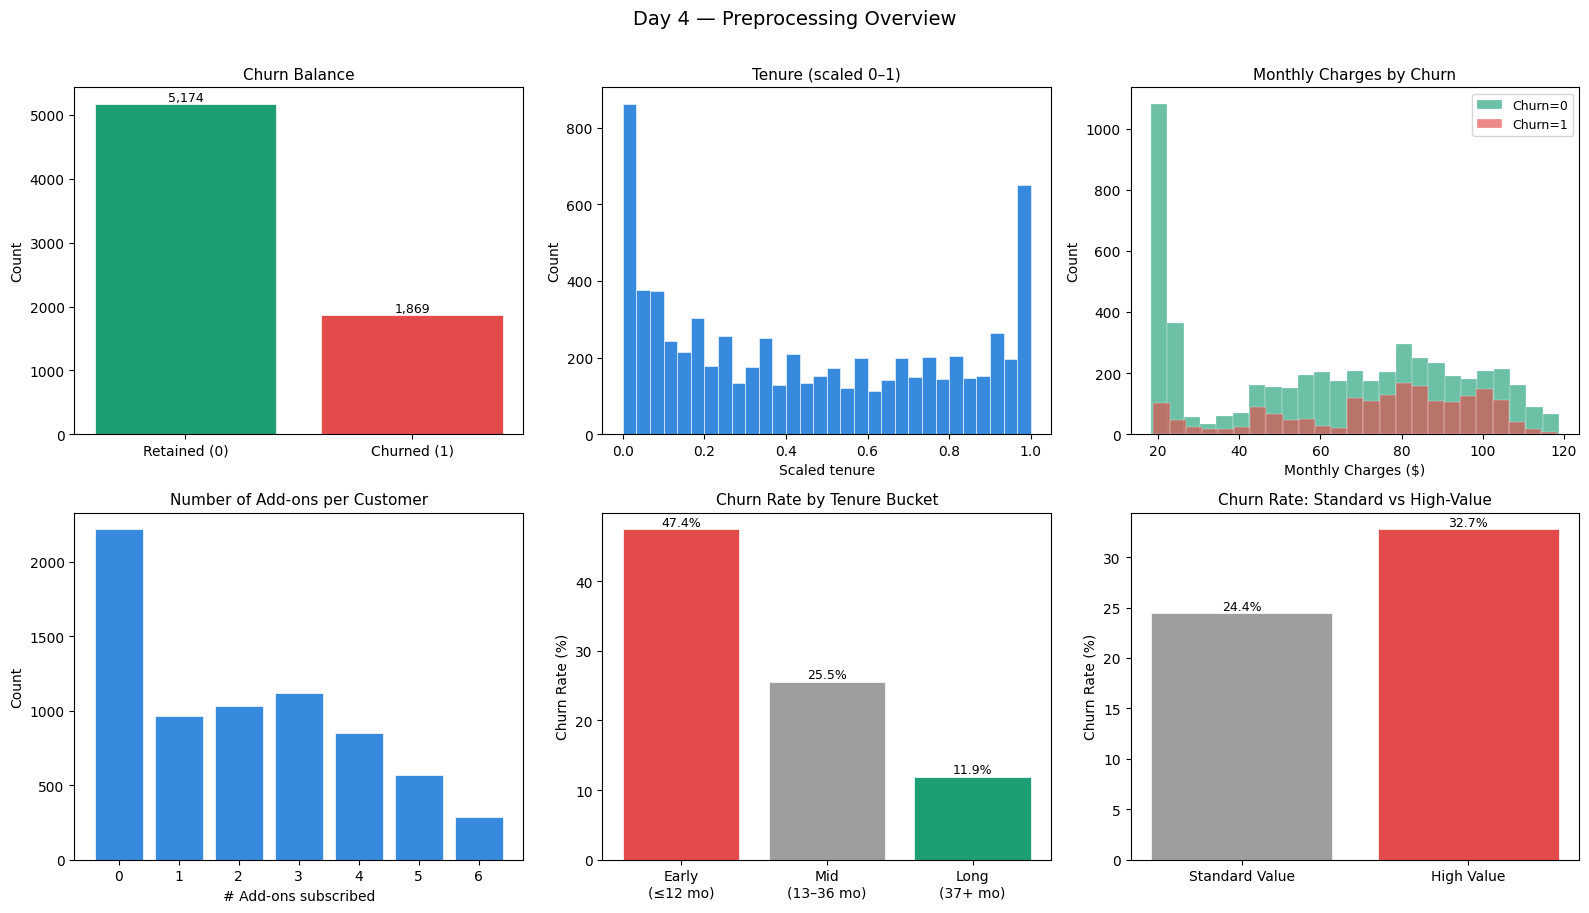

  Chart saved → C:/Users/white/Downloads/Learn/Churn_project/visuals/day4_preprocessing.png


In [10]:
# =============================================================================
# TASK 8 — PREPROCESSING SUMMARY VISUALISATION
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 8 — Preprocessing summary charts")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Day 4 — Preprocessing Overview", fontsize=14, fontweight="normal", y=1.01)

PALETTE = {"main": "#378ADD", "accent": "#E24B4A", "green": "#1D9E75", "grey": "#9E9E9E"}

# ── 8a: Churn balance (post-encoding) ────────────────────────────────────────
churn_counts = df["Churn"].value_counts()
axes[0, 0].bar(
    ["Retained (0)", "Churned (1)"],
    churn_counts.values,
    color=[PALETTE["green"], PALETTE["accent"]],
    edgecolor="white", linewidth=0.5
)
axes[0, 0].set_title("Churn Balance", fontsize=11)
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

# ── 8b: Scaled tenure distribution ───────────────────────────────────────────
axes[0, 1].hist(df["tenure"], bins=30, color=PALETTE["main"], edgecolor="white", linewidth=0.4)
axes[0, 1].set_title("Tenure (scaled 0–1)", fontsize=11)
axes[0, 1].set_xlabel("Scaled tenure")
axes[0, 1].set_ylabel("Count")

# ── 8c: MonthlyCharges by Churn ───────────────────────────────────────────────
for label, color in zip([0, 1], [PALETTE["green"], PALETTE["accent"]]):
    subset = df[df["Churn"] == label]["MonthlyCharges_raw"]
    axes[0, 2].hist(subset, bins=25, alpha=0.65, label=f"Churn={label}",
                    color=color, edgecolor="white", linewidth=0.3)
axes[0, 2].set_title("Monthly Charges by Churn", fontsize=11)
axes[0, 2].set_xlabel("Monthly Charges ($)")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend(fontsize=9)

# ── 8d: Add-ons distribution ──────────────────────────────────────────────────
addon_counts = df["num_addons"].value_counts().sort_index()
axes[1, 0].bar(addon_counts.index, addon_counts.values,
               color=PALETTE["main"], edgecolor="white", linewidth=0.5)
axes[1, 0].set_title("Number of Add-ons per Customer", fontsize=11)
axes[1, 0].set_xlabel("# Add-ons subscribed")
axes[1, 0].set_ylabel("Count")

# ── 8e: Tenure bucket vs Churn rate ──────────────────────────────────────────
bucket_churn = df.groupby("tenure_bucket")["Churn"].mean().mul(100)
axes[1, 1].bar(
    ["Early\n(≤12 mo)", "Mid\n(13–36 mo)", "Long\n(37+ mo)"],
    bucket_churn.values,
    color=[PALETTE["accent"], PALETTE["grey"], PALETTE["green"]],
    edgecolor="white", linewidth=0.5
)
axes[1, 1].set_title("Churn Rate by Tenure Bucket", fontsize=11)
axes[1, 1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(bucket_churn.values):
    axes[1, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# ── 8f: High-value vs churn ───────────────────────────────────────────────────
hv_churn = df.groupby("high_value")["Churn"].mean().mul(100)
axes[1, 2].bar(
    ["Standard Value", "High Value"],
    hv_churn.values,
    color=[PALETTE["grey"], PALETTE["accent"]],
    edgecolor="white", linewidth=0.5
)
axes[1, 2].set_title("Churn Rate: Standard vs High-Value", fontsize=11)
axes[1, 2].set_ylabel("Churn Rate (%)")
for i, v in enumerate(hv_churn.values):
    axes[1, 2].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Chart saved → {VISUALS_PATH}")

In [11]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  DAY 4 COMPLETE — KEY FINDINGS")
print("=" * 60)
print(f"  Final shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Null values remain  : {df.isnull().sum().sum()}")
print(f"  TotalCharges fixed  : blank strings → 0.0 for {tc_nulls_before} new customers")
print(f"  Columns encoded     : gender, Partner, Dependents, PhoneService,")
print(f"                        PaperlessBilling, Churn (binary)")
print(f"  OHE applied to      : MultipleLines, InternetService, Online*,")
print(f"                        Streaming*, Contract, PaymentMethod")
print(f"  Scaled (0–1)        : tenure, MonthlyCharges, TotalCharges")
print(f"  New features        : charge_per_month, high_value,")
print(f"                        num_addons, tenure_bucket, mtm_contract")
print("")
print("  TOMORROW — Day 5:")
print("  -> Exploratory correlation analysis (heatmap)")
print("  -> Deep-dive: which features drive churn most?")
print("  -> Statistical tests (chi-square, t-test)")
print("=" * 60)


  DAY 4 COMPLETE — KEY FINDINGS
  Final shape         : 7,043 rows × 49 columns
  Null values remain  : 0
  TotalCharges fixed  : blank strings → 0.0 for 11 new customers
  Columns encoded     : gender, Partner, Dependents, PhoneService,
                        PaperlessBilling, Churn (binary)
  OHE applied to      : MultipleLines, InternetService, Online*,
                        Streaming*, Contract, PaymentMethod
  Scaled (0–1)        : tenure, MonthlyCharges, TotalCharges
  New features        : charge_per_month, high_value,
                        num_addons, tenure_bucket, mtm_contract

  TOMORROW — Day 5:
  -> Exploratory correlation analysis (heatmap)
  -> Deep-dive: which features drive churn most?
  -> Statistical tests (chi-square, t-test)
